## Supervised Learning Premier

<p>
The quality of data and the amount of useful information it contains is very key to the results of the machine learning algorithms.
Its important to examine and preprocess data before feeding the data to machine learning algorithms
</p>

In [1]:
import pandas as pd
from io import StringIO

In [2]:
csv_data = '''
A,B,C,D
1.0, 2.0, 3.0, 4.0
5.0,6.0,8.0
10.0,11.0,12.0,
'''
df = pd.read_csv(StringIO(csv_data))
df

,A,B,C,D
0,1.0,2.0,3.0,4.0
1,5.0,6.0,8.0,NaN
2,10.0,11.0,12.0,NaN


In [3]:
df.isnull().sum()

A    0
B    0
C    0
D    2
dtype: int64

In [4]:
## drop rows with missing values 
df.dropna(axis = 0)

,A,B,C,D
0,1.0,2.0,3.0,4.0


In [5]:
## drop rows with missing values based on a certain column

df.dropna(subset=['D'], axis =0)

,A,B,C,D
0,1.0,2.0,3.0,4.0


<p>We can also drop columns that have atleast one NaN in any row</p>

In [6]:
df.dropna(axis =1)

,A,B,C
0,1.0,2.0,3.0
1,5.0,6.0,8.0
2,10.0,11.0,12.0


<p>
The danger of dropping NaN or missing data is that we can end up removing a lot of samples, which could leave us with
less than meaninful data to proceed with our modelling or to even learn fom the data.
</p>

<h3>Imputing Missing Values</h3>

<p>To avoid losing too much valuable data, we can adop another approach that interpolates numerical data hence 
replacing the missing values</p>

In [7]:
from sklearn.impute import SimpleImputer

In [8]:
imputer = SimpleImputer(strategy = 'mean',)
imputer.fit(df)

SimpleImputer()

In [9]:
imputer.statistics_

array([5.33333333, 6.33333333, 7.66666667, 4.        ])

In [10]:
#df.mean().values

In [11]:
df

,A,B,C,D
0,1.0,2.0,3.0,4.0
1,5.0,6.0,8.0,NaN
2,10.0,11.0,12.0,NaN


In [12]:
X = imputer.transform(df)

In [13]:
new_df = pd.DataFrame(X, columns = df.columns)
new_df

,A,B,C,D
0,1.0,2.0,3.0,4.0
1,5.0,6.0,8.0,4.0
2,10.0,11.0,12.0,4.0


<p>We replaced each null value with the mean, which has been computed for each column</p>

### Dealing with categorical data

<p>
Categorical data can be classified into ordinal and nominal data.
</p>

<p>Ordinal features: Are categorical values that can be ordered/ arranged/ sorted. For example a t-shirt size can be XL > L > M > S </p>
    

<p>Nominal features: Do not imply any order, for example it could be color, or Language type, we cannot say one is larger os smaller than the other</p>

In [14]:
df = pd.DataFrame([['Green', 'M', 10.1, 'class1'],
                 ['Red','L', 13.5, 'class2'],
                 ['Blue','XL',15.3, 'class1']])
df.columns = ['color', 'size', 'price','class_label']
df

,color,size,price,class_label
0,Green,M,10.1,class1
1,Red,L,13.5,class2
2,Blue,XL,15.3,class1


### Let's try to map ordinal categorical variables using an assumption, for example: 

XL = L + 1 = M + 2

In [15]:
size_mapping = {
    'XL': 3,
    'L' : 2,
    'M' : 1
}
df['size'] = df['size'].map(size_mapping)

In [16]:
df

,color,size,price,class_label
0,Green,1,10.1,class1
1,Red,2,13.5,class2
2,Blue,3,15.3,class1


#### If we want to reverse the mapping, this is what we can do

In [17]:
inverse_mapping = {v: k for k, v in size_mapping.items()} ## dictionary comprehension to produce another dictionary
df['size_r'] = df['size'].map(inverse_mapping)

In [18]:
df

,color,size,price,class_label,size_r
0,Green,1,10.1,class1,M
1,Red,2,13.5,class2,L
2,Blue,3,15.3,class1,XL


## Notes:

<p>
The zip() function is used to combine multiple iterables such as lists,
dictionaries and tuples into iterator of tuple. Each tuple will contain 
corresponding elements from the input iterables.
</p>

In [19]:
names = ["Fred","Alice","Andrew"]
scores = [78, 89, 78]

score_each = dict(zip(names, scores))

In [20]:
score_each

{'Fred': 78, 'Alice': 89, 'Andrew': 78}

In [21]:
paired = list(zip(names, scores))
print(paired)

[('Fred', 78), ('Alice', 89), ('Andrew', 78)]


In [22]:
### Unpacking a zipped object

names, scores = zip(*paired)
print(names)
print(scores)

('Fred', 'Alice', 'Andrew')
(78, 89, 78)


In [23]:
for name, score in zip(names, scores):
    print(f'{name} scored {score}')

Fred scored 78
Alice scored 89
Andrew scored 78


###### Handling unequal length variable iterables using: zip_longest

In [24]:
from itertools import zip_longest
list1 = [10, 45, 78]
list2 = ['A','B']

result = list(zip_longest(list1, list2, fillvalue ='N/A'))
print(result)

[(10, 'A'), (45, 'B'), (78, 'N/A')]


In [25]:
list(zip(list1, list2))

## as we can see above that zip will stop at the shortest one, and will not combine the iterables whose length has not been matched

[(10, 'A'), (45, 'B')]

#### Encoding class labels

In [26]:
import numpy as np
class_mapping = {label : idx for idx, label in enumerate(np.unique(df['class_label']))}
class_mapping

{'class1': 0, 'class2': 1}

In [27]:
df['class_label_ecoded'] = df['class_label'].map(class_mapping)
df

,color,size,price,class_label,size_r,class_label_ecoded
0,Green,1,10.1,class1,M,0
1,Red,2,13.5,class2,L,1
2,Blue,3,15.3,class1,XL,0


In [28]:
### An alternative way to do this is using SciKit learn, LbelEncoder

In [29]:
from sklearn.preprocessing import LabelEncoder ## mostly to encode class labels
from sklearn.preprocessing import OneHotEncoder

class_le = LabelEncoder()
y = class_le.fit_transform(df['class_label'])
y

array([0, 1, 0])

In [32]:
from sklearn.preprocessing import OneHotEncoder
colors = df[['color']]
encoder = OneHotEncoder()
color_encoded = encoder.fit_transform(colors)
color_encoded

<3x3 sparse matrix of type '<class 'numpy.float64'>'
	with 3 stored elements in Compressed Sparse Row format>

In [33]:
color_encoded.toarray()

array([[0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.]])

##### Another way to create the one-hot encoded features is by using Pandas' get_dummies method

In [34]:
pd.get_dummies(df[['price','color','size']],dtype=float,drop_first =True)

,price,size,color_Green,color_Red
0,10.1,1,1.0,0.0
1,13.5,2,0.0,1.0
2,15.3,3,0.0,0.0


###### To reduce correlation among variables, we can remove one feature column from the one-hot encoded array

## Logistic Regression

In real world machine learning, determining whether classes are linearly separable or non-linearly separable is crucial for selecting
the right model to use.

To know whether classes are linearly separable, we can either plot using scatter plots or pair plots, to determine the separability of the classes.

Another way to know whether the classes are linearly separable, is by applying the model, and testing the accuracy of the model. If the accuracy is high, then perhaps the classes are linearly 
separable, if the accuracy is low, then the classes are non-linearly separable, and we should therefore use other models.

Logistic regression works by computing the probability that an instance belongs to a certain class. It is a binary classifier
which works well on linearly separable classes.

Text(0, 0.5, '$\\phi (z)$')

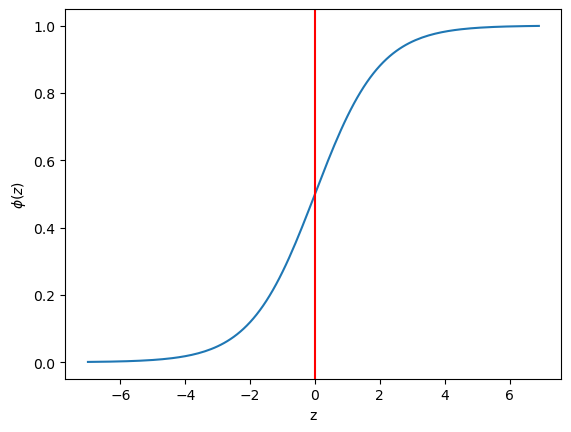

In [47]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

z = np.arange(-7, 7, 0.1)
phi_z = sigmoid(z)
plt.plot(z, phi_z)
plt.axvline(0.0, color = 'r')
plt.xlabel('z')
plt.ylabel('$\phi (z)$')

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn import datasets

iris = datasets.load_iris()

In [53]:
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [60]:
target_names = list(iris["target_names"])
target_data = list(iris["target"])

In [62]:
target_names

['setosa', 'versicolor', 'virginica']

In [63]:
target_map = {
    0: target_names[0],
    1: target_names[1],
    2: target_names[2]
}

In [64]:
target_map

{0: 'setosa', 1: 'versicolor', 2: 'virginica'}

In [73]:
target_data_mapped = pd.Series(target_data, name='class_names').map(target_map)
target_data_raw = pd.Series(target_data, name ='classes')

In [82]:
X = iris['data']
X.shape

(150, 4)

In [84]:
y = iris['target']
y.shape

(150,)

In [87]:
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits =1, test_size=0.2, random_state = 42)
for train_idx, test_idx in split.split(X,y):
    X_train = X[train_idx]
    X_test = X[test_idx]
    y_train = y[train_idx]
    y_test = y[test_idx]

In [ ]:
log_reg = LogisticRegression()